# 종합실습 2: 후판 공정 Scale 불량 영향 인자 분석

이 노트북은 과제 설명서, 변수 템플릿, 이전 기수 GitHub 레포, 전공자 Notion 메모를 참고해 새로 구성한 분류 분석 코드입니다.

분석 목표는 `scale` 불량 여부를 예측하고, 불량 발생에 영향을 주는 핵심 공정 인자를 도출하는 것입니다.


## 0. 분석 설계

- 목표변수: `scale` (`불량`=1, `양품`=0)
- 주요 가설: 열입력, 제거공정, 강종/규격 민감도, 판두께 매개효과
- 분석 흐름: 데이터 로딩 → 변수 정의 → 전처리/파생변수 → EDA/통계검정 → 분류모델 → 핵심인자 선정 → 개선 방향 정리
- 모델: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost(설치된 경우)

간결한 해석을 위해 결과 출력 코드 바로 아래에 핵심 해석 Markdown을 배치했습니다.


In [1]:
import os
import warnings
from pathlib import Path

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_score

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / 'SCALE불량.csv'
TEMPLATE_PATH = PROJECT_DIR / '260529_종합실습2_핵심인자(중요 설명변수) 정리 템플릿.xlsx'

print('project_dir:', PROJECT_DIR)
print('data_exists:', DATA_PATH.exists())
print('template_exists:', TEMPLATE_PATH.exists())
print('xgboost_available:', HAS_XGBOOST)


project_dir: /Users/jihyun/Documents/포빅아/빅데이터/종합실습2
data_exists: True
template_exists: False
xgboost_available: True


### 해석

- 현재 노트북 위치를 기준으로 원본 CSV와 변수 템플릿을 읽도록 구성했습니다.
- XGBoost가 설치되어 있으면 자동으로 모델 목록에 포함되고, 없으면 나머지 모델만 실행됩니다.


In [2]:
df_raw = pd.read_csv(DATA_PATH, encoding='cp949')

print(df_raw.shape)
display(df_raw.head())
display(df_raw.info())


(1000, 21)


,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
0,PLT_1001,03JAN2023:07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조
1,PLT_1002,03JAN2023:07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조
2,PLT_1003,03JAN2023:07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조
3,PLT_1004,03JAN2023:07:41:01,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조
4,PLT_1005,03JAN2023:07:52:40,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   plate_no         1000 non-null   object
 1   rolling_date     1000 non-null   object
 2   scale            1000 non-null   object
 3   spec_long        1000 non-null   object
 4   spec_country     1000 non-null   object
 5   steel_kind       1000 non-null   object
 6   pt_thick         1000 non-null   int64 
 7   pt_width         1000 non-null   int64 
 8   pt_length        1000 non-null   int64 
 9   hsb              1000 non-null   object
 10  fur_no           1000 non-null   object
 11  fur_input_row    1000 non-null   object
 12  fur_heat_temp    1000 non-null   int64 
 13  fur_heat_time    1000 non-null   int64 
 14  fur_soak_temp    1000 non-null   int64 
 15  fur_soak_time    1000 non-null   int64 
 16  fur_total_time   1000 non-null   int64 
 17  rolling_method   1000 non-null   o

None

In [3]:
df_raw.columns

Index(['plate_no', 'rolling_date', 'scale', 'spec_long', 'spec_country', 'steel_kind', 'pt_thick', 'pt_width', 'pt_length', 'hsb', 'fur_no', 'fur_input_row',
       'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_method', 'rolling_temp', 'descaling_count',
       'work_group'],
      dtype='object')

### 해석

- 변수 템플릿은 ID/날짜/목표변수/설명변수를 구분하는 기준으로 사용합니다.
- `plate_no`는 식별자이므로 모델 입력에서 제외하고, `rolling_date`는 원본 대신 시간 파생변수로 활용합니다.


-------

#### 변수 처리 전 히트맵

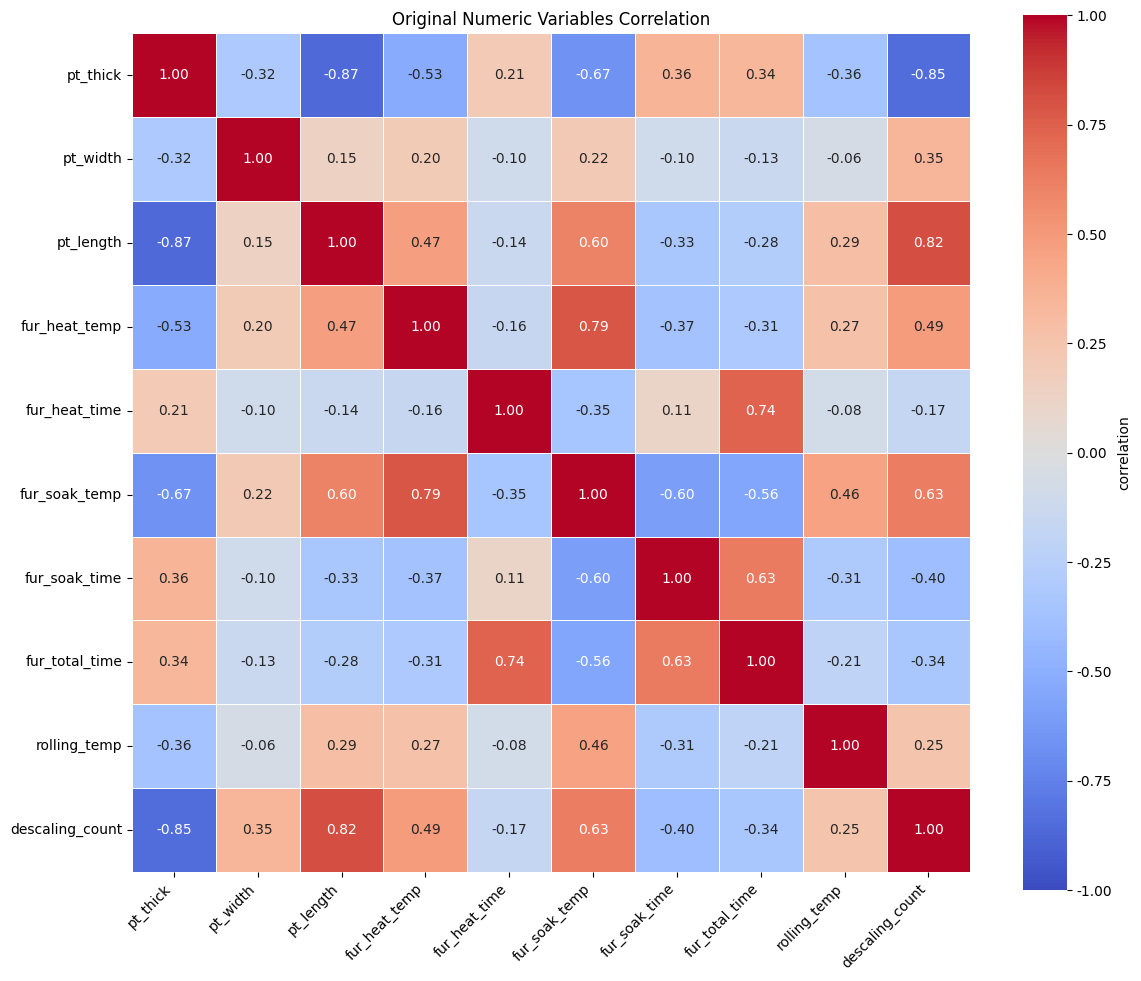

In [4]:
# 원본 연속형 변수만 (파생변수 제외)
raw_num_cols = [
    'pt_thick', 'pt_width', 'pt_length',
    'fur_heat_temp', 'fur_heat_time',
    'fur_soak_temp', 'fur_soak_time', 'fur_total_time',
    'rolling_temp', 'descaling_count'
]

corr_raw = df_raw[raw_num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_raw,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'correlation'}
)
plt.title('Original Numeric Variables Correlation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### 상관계수 확인 후, 파생변수 생성

In [5]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 목표변수: 불량=1, 양품=0
    out['scale_bad'] = (out['scale'].astype(str).str.strip() == '불량').astype(int)

    # 날짜 파싱: 예) 03JAN2023:07:07:53
    out['rolling_dt'] = pd.to_datetime(out['rolling_date'], format='%d%b%Y:%H:%M:%S', errors='coerce')
    out['rolling_hour'] = out['rolling_dt'].dt.hour    # 설비의 영향 받음
    out['rolling_dayofweek'] = out['rolling_dt'].dt.dayofweek
    out['rolling_shift'] = np.where(out['rolling_hour'].between(7, 18, inclusive='both'), 'day', 'night')    # 작업자 근무시간에 영향 받음

    out['side_area'] = out['pt_thick'] * out['pt_length']
    out['temp_diff'] = out['fur_soak_temp'] - out['fur_heat_temp']
    return out

df = prepare_data(df_raw)

summary = pd.DataFrame({
    'missing': df.isna().sum(),
    'n_unique': df.nunique(),
    'dtype': df.dtypes.astype(str)
}).sort_index()

display(summary)
display(df['scale'].value_counts().to_frame('count').assign(rate=lambda x: x['count'] / len(df)))


,missing,n_unique,dtype
descaling_count,0,6,int64
fur_heat_temp,0,100,int64
fur_heat_time,0,100,int64
fur_input_row,0,2,object
fur_no,0,3,object
fur_soak_temp,0,70,int64
fur_soak_time,0,100,int64
fur_total_time,0,170,int64
hsb,0,2,object
plate_no,0,1000,object


,count,rate
양품,690,0.69
불량,310,0.31


In [6]:
print(df.columns.tolist())

['plate_no', 'rolling_date', 'scale', 'spec_long', 'spec_country', 'steel_kind', 'pt_thick', 'pt_width', 'pt_length', 'hsb', 'fur_no', 'fur_input_row', 'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_method', 'rolling_temp', 'descaling_count', 'work_group', 'scale_bad', 'rolling_dt', 'rolling_hour', 'rolling_dayofweek', 'rolling_shift', 'side_area', 'temp_diff']


### 해석

- `scale_bad`는 모델링용 이진 목표변수입니다.
- 불량률이 낮으면 정확도만으로 모델을 평가하면 안 됩니다. 이후 Recall, F1, ROC-AUC, PR-AUC를 함께 봅니다.
- 열입력(`dose`), 두께 보정, 온도 강하, descaling 충분성 변수를 추가해 공정 가설을 직접 검증할 수 있게 했습니다.


# !!!! 사용되는 설명 변수 확인 필수 !!!!!

In [7]:
# 제외할 변수 명시
exclude_cols = [
    'plate_no', 'rolling_date', 'rolling_dt',  # ID/날짜
    'scale',                                     # 타겟 원본
    'hsb_apply',                                 # hsb와 중복
    'rolling_dayofweek',                         # rolling_shift로 대체
    'pt_length', 'pt_thick',                     # area에 흡수
    'fur_soak_temp', 'fur_heat_temp',            # temp_gradient에 흡수
    'fur_total_time',                            # 다중공선성
    'scale_bad'                                  # 타겟 변수
]

# 사용할 변수만 추출
use_cols = [c for c in df.columns if c not in exclude_cols]

# 자동으로 연속형/범주형 분리
num_cols = [c for c in use_cols if df[c].dtype in ['int64', 'float64'] and df[c].nunique() > 1]
cat_cols = [c for c in use_cols if df[c].dtype == 'object' and df[c].nunique() > 1]

print('numeric:', num_cols)
print('categorical:', cat_cols)

numeric: ['pt_width', 'fur_heat_time', 'fur_soak_time', 'rolling_temp', 'descaling_count', 'rolling_hour', 'side_area', 'temp_diff']
categorical: ['spec_long', 'spec_country', 'steel_kind', 'hsb', 'fur_no', 'fur_input_row', 'rolling_method', 'work_group', 'rolling_shift']


### 연속형 변수 이상치 확인

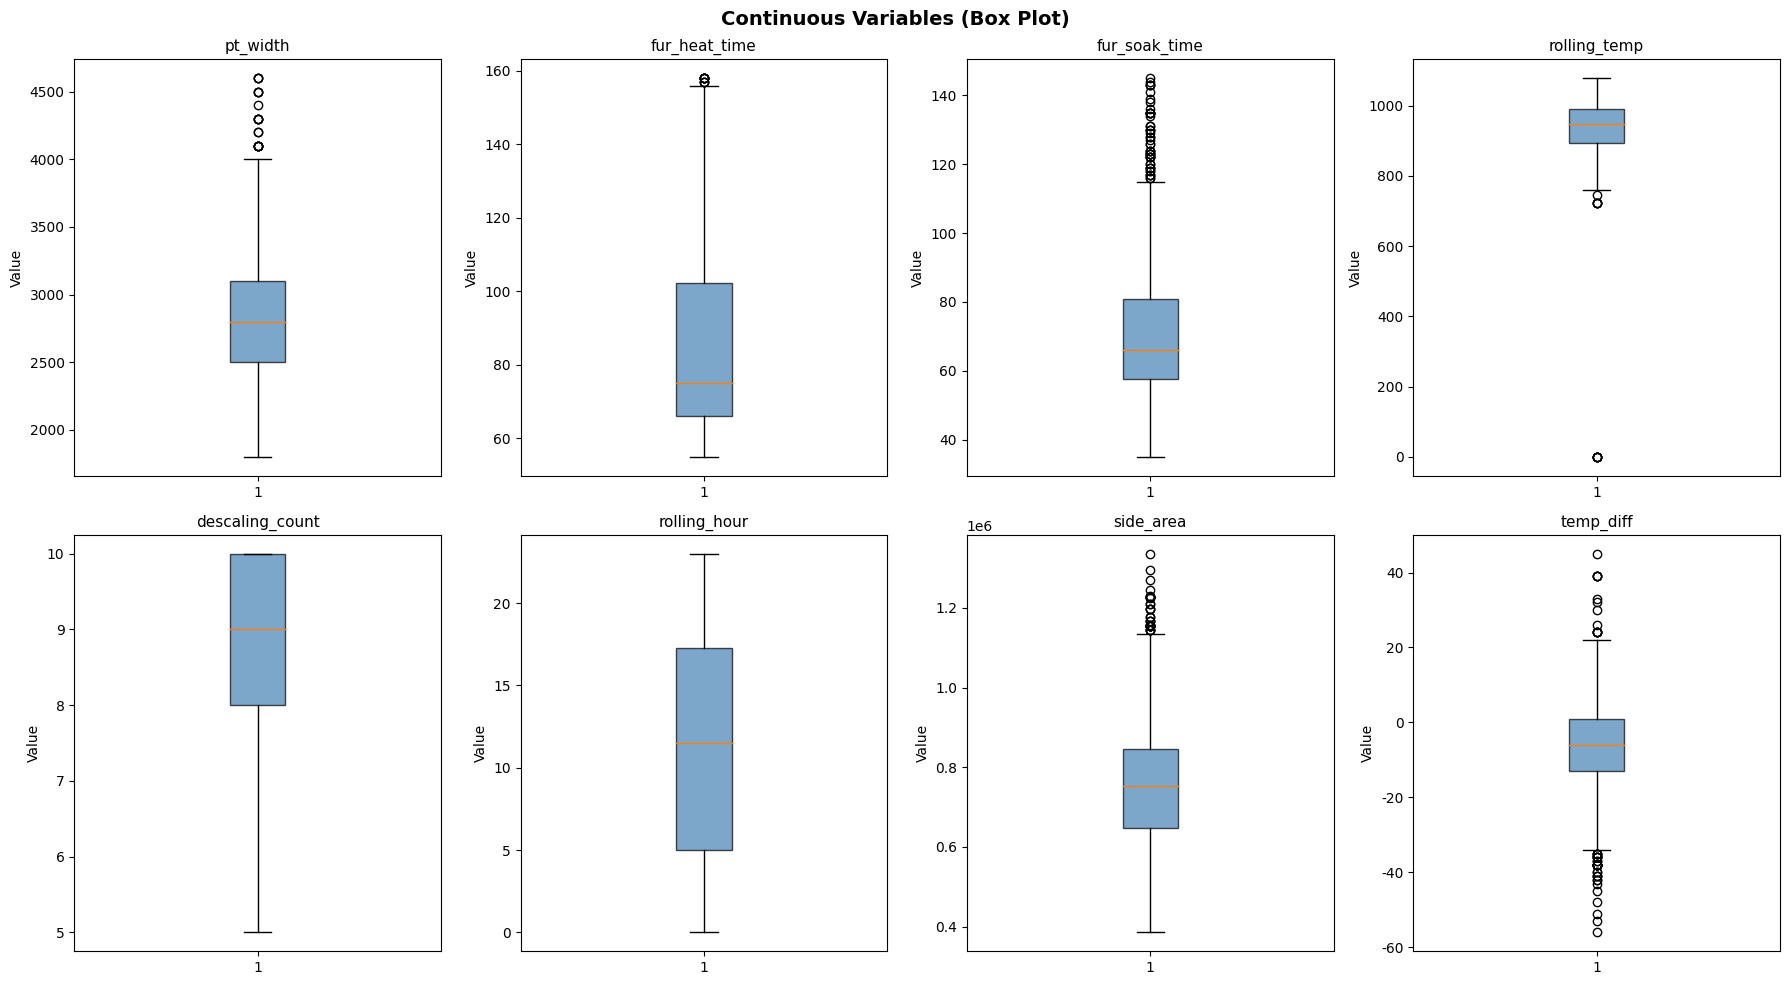

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Continuous Variables (Box Plot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### rolling_temp 정확한 이상치 값 확인

In [9]:
print(df['rolling_temp'].sort_values().head(20))

221      0
53       0
599      0
600      0
222      0
598      0
632    723
633    723
631    723
634    723
549    745
102    760
101    760
99     773
100    773
530    802
531    805
57     808
621    811
620    811
Name: rolling_temp, dtype: int64


In [10]:
print(df.shape)

(1000, 28)


In [11]:
print(df[num_cols].describe())

          pt_width  fur_heat_time  fur_soak_time  rolling_temp  descaling_count  rolling_hour     side_area    temp_diff
count  1000.000000    1000.000000    1000.000000   1000.000000      1000.000000   1000.000000  1.000000e+03  1000.000000
mean   2831.900000      85.972000      71.720000    934.637000         8.557000     11.493000  7.666727e+05    -6.317000
std     494.081478      26.346297      20.602137     96.598015         1.604158      6.970979  1.622440e+05    13.116347
min    1800.000000      55.000000      35.000000      0.000000         5.000000      0.000000  3.856000e+05   -56.000000
25%    2500.000000      66.000000      57.750000    893.750000         8.000000      5.000000  6.476250e+05   -13.000000
50%    2800.000000      75.000000      66.000000    948.000000         9.000000     11.500000  7.518000e+05    -6.000000
75%    3100.000000     102.250000      81.000000    991.000000        10.000000     17.250000  8.448000e+05     1.000000
max    4600.000000     158.00000

In [12]:
print(num_cols)
print(cat_cols)

['pt_width', 'fur_heat_time', 'fur_soak_time', 'rolling_temp', 'descaling_count', 'rolling_hour', 'side_area', 'temp_diff']
['spec_long', 'spec_country', 'steel_kind', 'hsb', 'fur_no', 'fur_input_row', 'rolling_method', 'work_group', 'rolling_shift']


### rolling_temp(압연 온도) 0 인 것 drop

In [13]:
df = df[df['rolling_temp'] > 0].reset_index(drop=True)
print(len(df))

994


----------

#### t-test 검정

,variable,bad_mean,good_mean,bad-good,p_value
3,rolling_temp,988.754839,918.308480,70.446359,6.790361e-66
2,fur_soak_time,64.974194,74.815789,-9.841596,2.941014e-15
0,pt_width,2692.258065,2898.245614,-205.987550,1.647683e-09
6,side_area,808909.354839,746811.549708,62097.805131,3.648726e-08
7,temp_diff,-4.887097,-6.983918,2.096821,1.291017e-02
4,descaling_count,8.461290,8.611111,-0.149821,1.364503e-01
5,rolling_hour,11.041935,11.671053,-0.629117,1.777905e-01
1,fur_heat_time,84.564516,86.624269,-2.059753,2.294096e-01


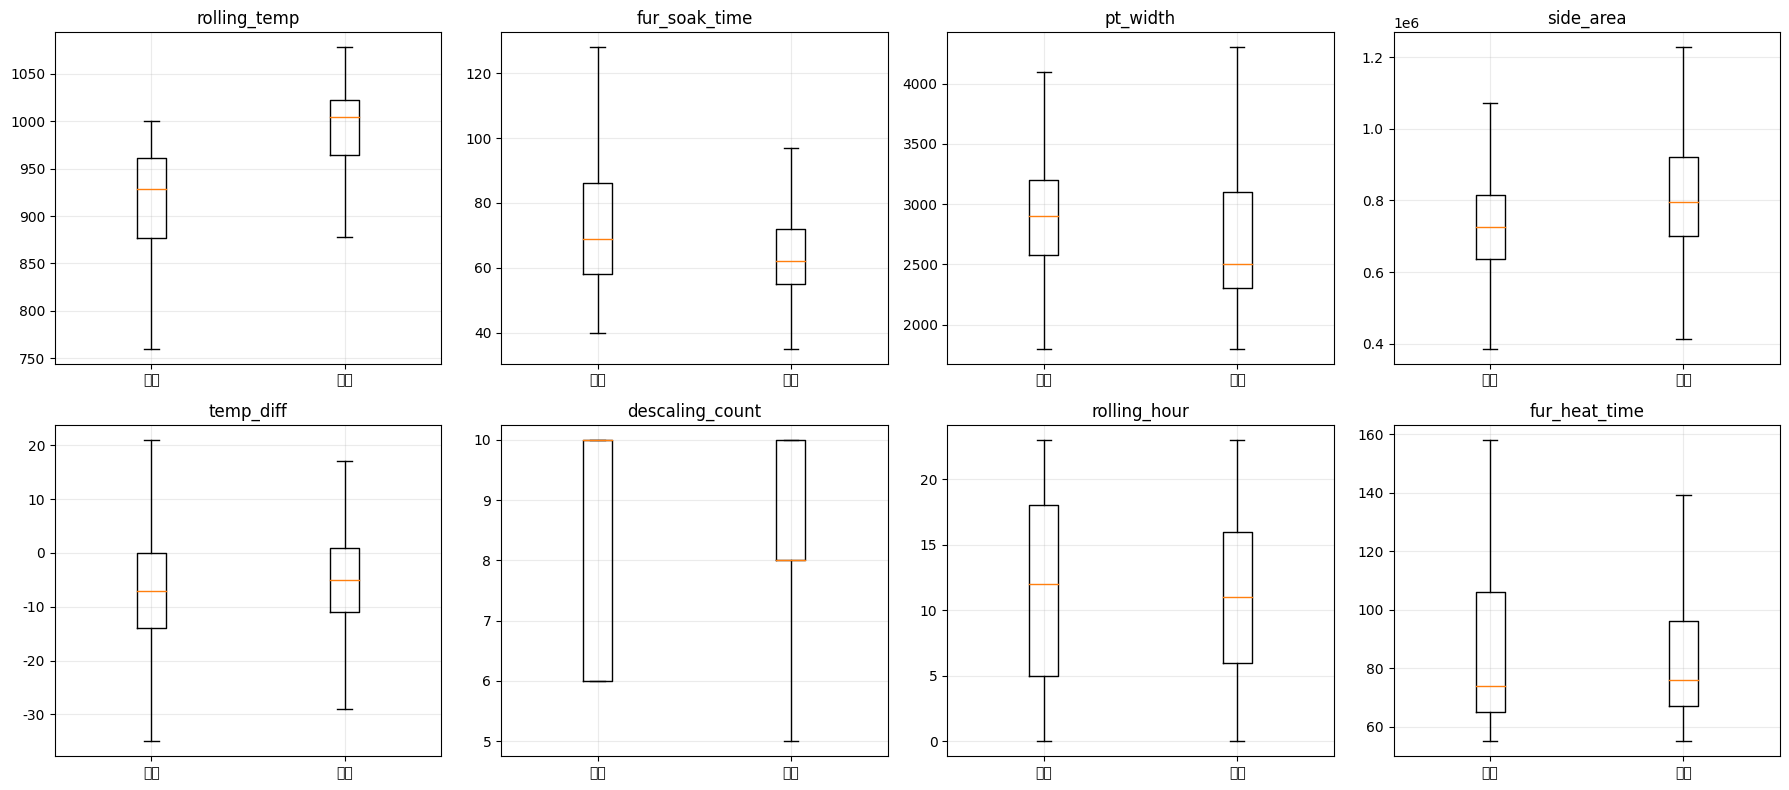

In [14]:
# 수치형 변수: 양품/불량 평균 차이와 t-test
num_test_rows = []

for col in num_cols:
    good = df.loc[df['scale_bad'] == 0, col].dropna()
    bad = df.loc[df['scale_bad'] == 1, col].dropna()
    if len(good) >= 2 and len(bad) >= 2:
        t_stat, p_val = stats.ttest_ind(bad, good, equal_var=False)
        num_test_rows.append({
            'variable': col,
            'bad_mean': bad.mean(),
            'good_mean': good.mean(),
            'bad-good': bad.mean() - good.mean(),
            'p_value': p_val
        })

num_tests = pd.DataFrame(num_test_rows).sort_values('p_value')
display(num_tests.head(20))

# 상위 수치형 변수 시각화
plot_cols = num_tests.head(8)['variable'].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    groups = [df.loc[df['scale_bad'] == 0, col].dropna(), df.loc[df['scale_bad'] == 1, col].dropna()]
    ax.boxplot(groups, labels=['양품', '불량'], showfliers=False)
    ax.set_title(col)
    ax.grid(alpha=0.25)
    
plt.tight_layout()
plt.show()


In [15]:
num_tests_display = num_tests.copy()
num_tests_display['p_value'] = num_tests_display['p_value'].apply(
    lambda x: '< 0.0001' if x < 0.0001 else f'{x:.4f}'
)
num_tests_display['bad_mean'] = num_tests_display['bad_mean'].round(2)
num_tests_display['good_mean'] = num_tests_display['good_mean'].round(2)
num_tests_display['bad-good'] = num_tests_display['bad-good'].round(2)
num_tests_display['유의여부'] = num_tests['p_value'].apply(lambda x: '유의' if x < 0.05 else '유의하지 않음')

display(num_tests_display)

,variable,bad_mean,good_mean,bad-good,p_value,유의여부
3,rolling_temp,988.75,918.31,70.45,< 0.0001,유의
2,fur_soak_time,64.97,74.82,-9.84,< 0.0001,유의
0,pt_width,2692.26,2898.25,-205.99,< 0.0001,유의
6,side_area,808909.35,746811.55,62097.81,< 0.0001,유의
7,temp_diff,-4.89,-6.98,2.10,0.0129,유의
4,descaling_count,8.46,8.61,-0.15,0.1365,유의하지 않음
5,rolling_hour,11.04,11.67,-0.63,0.1778,유의하지 않음
1,fur_heat_time,84.56,86.62,-2.06,0.2294,유의하지 않음


### 해석

- p-value가 낮고 `bad-good` 차이가 큰 변수는 불량군과 양품군의 공정 조건이 다르다는 신호입니다.
- 단, 통계검정은 단변량 기준입니다. 공정 변수끼리 상관이 있으므로 최종 핵심인자는 모델 중요도와 기술적 타당성을 함께 봐야 합니다.


----------
#### 카이제곱 검정

In [16]:
# 범주형 변수: 카이제곱 검정과 불량률
cat_test_rows = []

for col in cat_cols:
    tab = pd.crosstab(df[col], df['scale_bad'])
    if tab.shape[0] >= 2 and tab.shape[1] == 2:
        chi2, p_val, dof, expected = chi2_contingency(tab)
        bad_rate = df.groupby(col)['scale_bad'].mean().sort_values(ascending=False)
        cat_test_rows.append({
            'variable': col,
            'n_level': df[col].nunique(),
            'chi2': chi2,
            'p_value': p_val,
            'top_bad_rate_level': bad_rate.index[0],
            'top_bad_rate': bad_rate.iloc[0]
        })

cat_tests = pd.DataFrame(cat_test_rows).sort_values('p_value')
display(cat_tests)

# 상위 범주형 변수 불량률
for col in cat_tests.head(6)['variable']:
    rate = df.groupby(col)['scale_bad'].agg(['mean','count']).sort_values('mean', ascending=False)
    rate_view = rate.head(12).copy()
    rate_view['mean'] = (rate_view['mean'] * 100).round(1).astype(str) + '%'
    
    print(f'\n{col}별 불량률')
    display(rate_view)


,variable,n_level,chi2,p_value,top_bad_rate_level,top_bad_rate
3,hsb,2,105.510486,9.439705e-25,미적용,1.000000
0,spec_long,66,235.946857,3.113316e-21,A131-DH36TM,1.000000
2,steel_kind,2,76.257742,2.489547e-18,C,0.385126
1,spec_country,7,69.800750,4.492256e-13,일본,0.524324
6,rolling_method,2,44.880032,2.094833e-11,CR(제어압연),0.355263
7,work_group,4,13.900577,3.043656e-03,1조,0.390681
8,rolling_shift,2,7.831046,5.135637e-03,day,0.354251
4,fur_no,3,3.118622,2.102809e-01,3호기,0.346154
5,fur_input_row,2,0.920367,3.373786e-01,1열,0.326733



hsb별 불량률


,mean,count
hsb,,
미적용,100.0%,47
적용,27.8%,947



spec_long별 불량률


,mean,count
spec_long,,
A131-DH36TM,100.0%,1
CCS-B,100.0%,2
LR-EH32-TM,100.0%,1
KS-SM490A,100.0%,5
KR-B,100.0%,1
JS-SM400A,100.0%,2
BV-AH36-TM,100.0%,1
JS-SS400,91.7%,24
A283-C,83.3%,6


...

,mean,count
spec_country,,
일본,52.4%,185
한국,37.7%,130
영국,29.4%,255
미국,27.7%,159
프랑스,20.3%,143
독일,15.1%,86
공통,8.3%,36



rolling_method별 불량률


,mean,count
rolling_method,,
CR(제어압연),35.5%,836
TMCP(온도제어),8.2%,158



work_group별 불량률


,mean,count
work_group,,
1조,39.1%,279
3조,30.7%,215
2조,29.3%,290
4조,23.8%,210


In [17]:
cat_tests_display = cat_tests.copy()
cat_tests_display['p_value'] = cat_tests_display['p_value'].apply(
    lambda x: '< 0.0001' if x < 0.0001 else f'{x:.4f}'
)
cat_tests_display['chi2'] = cat_tests_display['chi2'].round(2)
cat_tests_display['top_bad_rate'] = (cat_tests_display['top_bad_rate'] * 100).round(1).astype(str) + '%'
cat_tests_display['유의여부'] = cat_tests['p_value'].apply(lambda x: '유의' if x < 0.05 else '유의하지 않음')

display(cat_tests_display)

,variable,n_level,chi2,p_value,top_bad_rate_level,top_bad_rate,유의여부
3,hsb,2,105.51,< 0.0001,미적용,100.0%,유의
0,spec_long,66,235.95,< 0.0001,A131-DH36TM,100.0%,유의
2,steel_kind,2,76.26,< 0.0001,C,38.5%,유의
1,spec_country,7,69.80,< 0.0001,일본,52.4%,유의
6,rolling_method,2,44.88,< 0.0001,CR(제어압연),35.5%,유의
7,work_group,4,13.90,0.0030,1조,39.1%,유의
8,rolling_shift,2,7.83,0.0051,day,35.4%,유의
4,fur_no,3,3.12,0.2103,3호기,34.6%,유의하지 않음
5,fur_input_row,2,0.92,0.3374,1열,32.7%,유의하지 않음


### 해석

- 카이제곱 p-value가 낮은 범주형 변수는 불량 여부와 독립이 아닐 가능성이 큽니다.
- `hsb`, `steel_kind`, `rolling_method`처럼 공정 메커니즘과 연결되는 변수는 모델에서도 우선 확인할 후보입니다.


## 범주형 변수 인코딩

In [18]:
for col in cat_cols:
    print(f'\n{col} ({df[col].nunique()}개)')
    print(df[col].value_counts())


spec_long (66개)
JS-SM490YB     82
LR-A           81
LR-AH32        52
AB/A           51
NV-A           48
               ..
LR-AH36         1
BV-AH36-TM      1
A131-DH36TM     1
KR-B            1
KS-HSB600       1
Name: spec_long, Length: 66, dtype: int64

spec_country (7개)
영국     255
일본     185
미국     159
프랑스    143
한국     130
독일      86
공통      36
Name: spec_country, dtype: int64

steel_kind (2개)
C    753
T    241
Name: steel_kind, dtype: int64

hsb (2개)
적용     947
미적용     47
Name: hsb, dtype: int64

fur_no (3개)
3호기    338
1호기    332
2호기    324
Name: fur_no, dtype: int64

fur_input_row (2개)
1열    505
2열    489
Name: fur_input_row, dtype: int64

rolling_method (2개)
CR(제어압연)      836
TMCP(온도제어)    158
Name: rolling_method, dtype: int64

work_group (4개)
2조    290
1조    279
3조    215
4조    210
Name: work_group, dtype: int64

rolling_shift (2개)
night    500
day      494
Name: rolling_shift, dtype: int64


In [19]:
top10 = df['spec_long'].value_counts().head(10).index
print(df['spec_long'].value_counts().head(10))

JS-SM490YB    82
LR-A          81
LR-AH32       52
AB/A          51
NV-A          48
KR-A          46
BV-EH36-TM    39
PILAC-BT33    38
COMMON        36
BV-B          34
Name: spec_long, dtype: int64


In [20]:
pd.set_option('display.max_rows', None)
print(df['spec_long'].value_counts())
pd.reset_option('display.max_rows')

JS-SM490YB     82
LR-A           81
LR-AH32        52
AB/A           51
NV-A           48
KR-A           46
BV-EH36-TM     39
PILAC-BT33     38
COMMON         36
BV-B           34
BV-AH32        34
NV-A32         33
JS-SM490A      33
AB/EH36-TM     32
AB/AH32        31
GL-A32         24
JS-SS400       24
SA283-C        21
BV-A           19
NK-KA32        19
GL-A           17
GL-E36-TM      15
LR-B           13
KR-AH32        11
GL-A36-TM      11
NK-KA          10
AB/B            9
GL-D36-TM       9
BV-EH32-TM      7
KS-SM490B       7
KS-SM400B       6
GL-E32-TM       6
JS-SM400B       6
A283-C          6
JS-SM490YA      5
KS-SM490A       5
NV-D36-TM       5
KS-SS400        5
NV-E36-TM       5
V42JBN3         4
BV-AH32-TM      4
KS-SM400A       4
GL-A32-TM       4
BV-AH36-TL      3
NV-B            3
A516-60         3
NK-KD36-TM      3
NV-D32-TM       3
NV-A32-TM       3
NV-A36-TM       2
API-2W-50T      2
AB/EH32-TM      2
KS-HSB500       2
NV-E32-TM       2
CCS-B           2
LR-EH36-TM

In [21]:
# 1단계: spec_long Other 처리
counts = df['spec_long'].value_counts()
keep = counts[counts >= 10].index
df['spec_long'] = df['spec_long'].where(df['spec_long'].isin(keep), 'Other')

print(df['spec_long'].value_counts())
print('범주 수:', df['spec_long'].nunique())

# 2단계: 전체 인코딩
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print('인코딩 전:', df.shape)
print('인코딩 후:', df_encoded.shape)
print('\n생성된 컬럼들:')
print(df_encoded.columns.tolist())

Other         140
JS-SM490YB     82
LR-A           81
LR-AH32        52
AB/A           51
NV-A           48
KR-A           46
BV-EH36-TM     39
PILAC-BT33     38
COMMON         36
BV-B           34
BV-AH32        34
JS-SM490A      33
NV-A32         33
AB/EH36-TM     32
AB/AH32        31
GL-A32         24
JS-SS400       24
SA283-C        21
NK-KA32        19
BV-A           19
GL-A           17
GL-E36-TM      15
LR-B           13
KR-AH32        11
GL-A36-TM      11
NK-KA          10
Name: spec_long, dtype: int64
범주 수: 27
인코딩 전: (994, 28)
인코딩 후: (994, 61)

생성된 컬럼들:
['plate_no', 'rolling_date', 'scale', 'pt_thick', 'pt_width', 'pt_length', 'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_temp', 'descaling_count', 'scale_bad', 'rolling_dt', 'rolling_hour', 'rolling_dayofweek', 'side_area', 'temp_diff', 'spec_long_AB/AH32', 'spec_long_AB/EH36-TM', 'spec_long_BV-A', 'spec_long_BV-AH32', 'spec_long_BV-B', 'spec_long_BV-EH36-TM', 'spec_long_COMMON',

,abs_corr_with_target,corr
rolling_temp,0.511333,0.511333
fur_soak_time,0.220873,-0.220873
pt_width,0.193817,-0.193817
side_area,0.177632,0.177632
temp_diff,0.073901,0.073901
descaling_count,0.043415,-0.043415
rolling_hour,0.041761,-0.041761
fur_heat_time,0.036178,-0.036178


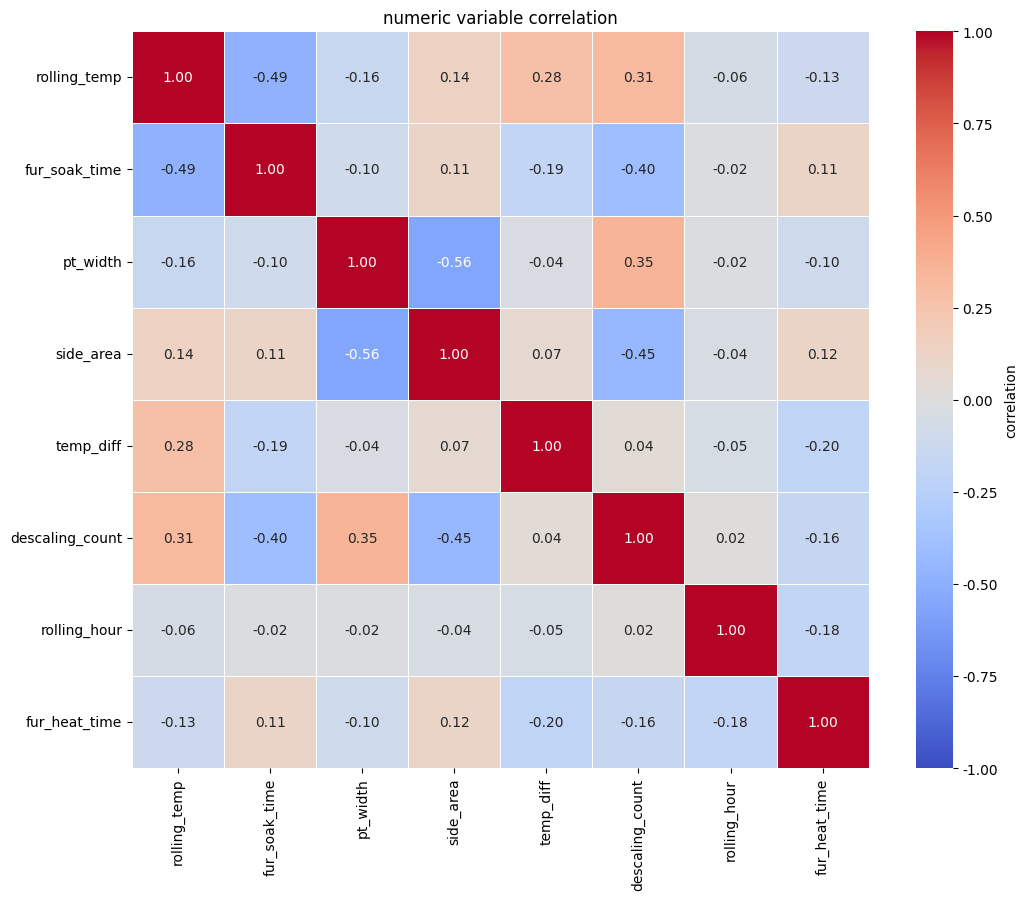

In [22]:

# 상관 확인: 공선성 위험 변수 파악
corr_cols = [c for c in num_cols if df[c].nunique(dropna=True) > 2]
corr = df[corr_cols + ['scale_bad']].corr(numeric_only=True)

top_corr = corr['scale_bad'].drop('scale_bad').abs().sort_values(ascending=False).head(15)
display(pd.DataFrame({'abs_corr_with_target': top_corr, 'corr': corr.loc[top_corr.index, 'scale_bad']}))

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr.loc[top_corr.index, top_corr.index],
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'correlation'}
)
plt.title('numeric variable correlation')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 해석

- `fur_total_time`, `heat_time`, `soak_time`, 열입력 파생변수는 서로 강하게 연동될 수 있습니다.
- 회귀계수 해석 시에는 공선성에 주의하고, 트리/퍼뮤테이션 중요도와 함께 판단합니다.


### 해석

- 클래스 불균형이 있으므로 Accuracy보다 불량 Recall, F1, PR-AUC를 우선합니다.
- 실제 현장 목적이 “불량을 놓치지 않는 것”이면 Recall을 더 중시하고, 과검출 비용이 크면 Precision과 F1의 균형을 봅니다.


---------
#### 모델 

In [23]:
print(df_encoded.columns.tolist())

['plate_no', 'rolling_date', 'scale', 'pt_thick', 'pt_width', 'pt_length', 'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_temp', 'descaling_count', 'scale_bad', 'rolling_dt', 'rolling_hour', 'rolling_dayofweek', 'side_area', 'temp_diff', 'spec_long_AB/AH32', 'spec_long_AB/EH36-TM', 'spec_long_BV-A', 'spec_long_BV-AH32', 'spec_long_BV-B', 'spec_long_BV-EH36-TM', 'spec_long_COMMON', 'spec_long_GL-A', 'spec_long_GL-A32', 'spec_long_GL-A36-TM', 'spec_long_GL-E36-TM', 'spec_long_JS-SM490A', 'spec_long_JS-SM490YB', 'spec_long_JS-SS400', 'spec_long_KR-A', 'spec_long_KR-AH32', 'spec_long_LR-A', 'spec_long_LR-AH32', 'spec_long_LR-B', 'spec_long_NK-KA', 'spec_long_NK-KA32', 'spec_long_NV-A', 'spec_long_NV-A32', 'spec_long_Other', 'spec_long_PILAC-BT33', 'spec_long_SA283-C', 'spec_country_독일', 'spec_country_미국', 'spec_country_영국', 'spec_country_일본', 'spec_country_프랑스', 'spec_country_한국', 'steel_kind_T', 'hsb_적용', 'fur_no_2호기', 'fur_no_3호기', 'fur_inp

In [24]:
# 인코딩된 범주형 컬럼 추출
encoded_cat_cols = [c for c in df_encoded.columns if any(c.startswith(cat + '_') for cat in cat_cols)]

# 최종 feature 컬럼
feature_cols = num_cols + encoded_cat_cols

X = df_encoded[feature_cols].copy()
y = df_encoded['scale_bad'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# preprocess: 연속형만 표준화, 인코딩된 범주형은 그대로
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)

print('feature 수:', len(feature_cols))
print('num_cols:', len(num_cols))
print('encoded_cat_cols:', len(encoded_cat_cols))
print(feature_cols)

feature 수: 50
num_cols: 8
encoded_cat_cols: 42
['pt_width', 'fur_heat_time', 'fur_soak_time', 'rolling_temp', 'descaling_count', 'rolling_hour', 'side_area', 'temp_diff', 'spec_long_AB/AH32', 'spec_long_AB/EH36-TM', 'spec_long_BV-A', 'spec_long_BV-AH32', 'spec_long_BV-B', 'spec_long_BV-EH36-TM', 'spec_long_COMMON', 'spec_long_GL-A', 'spec_long_GL-A32', 'spec_long_GL-A36-TM', 'spec_long_GL-E36-TM', 'spec_long_JS-SM490A', 'spec_long_JS-SM490YB', 'spec_long_JS-SS400', 'spec_long_KR-A', 'spec_long_KR-AH32', 'spec_long_LR-A', 'spec_long_LR-AH32', 'spec_long_LR-B', 'spec_long_NK-KA', 'spec_long_NK-KA32', 'spec_long_NV-A', 'spec_long_NV-A32', 'spec_long_Other', 'spec_long_PILAC-BT33', 'spec_long_SA283-C', 'spec_country_독일', 'spec_country_미국', 'spec_country_영국', 'spec_country_일본', 'spec_country_프랑스', 'spec_country_한국', 'steel_kind_T', 'hsb_적용', 'fur_no_2호기', 'fur_no_3호기', 'fur_input_row_2열', 'rolling_method_TMCP(온도제어)', 'work_group_2조', 'work_group_3조', 'work_group_4조', 'rolling_shift_night']


In [25]:
# 인코딩된 범주형 컬럼 추출
encoded_cat_cols = [c for c in df_encoded.columns if any(c.startswith(cat + '_') for cat in cat_cols)]
feature_cols = num_cols + encoded_cat_cols

X = df_encoded[feature_cols].copy()
y = df_encoded['scale_bad'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ohe 불필요 → 삭제
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)

models = {
    'Logistic': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=10, class_weight='balanced', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=42
    )
}

fitted = {}
metric_rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    metric_rows.append({
    'model': name,
    'accuracy': accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred, zero_division=0),
    'recall': recall_score(y_test, pred, zero_division=0),
    'f1': f1_score(y_test, pred, zero_division=0),
    'auc': roc_auc_score(y_test, proba)
})

metrics = pd.DataFrame(metric_rows).sort_values(['f1','auc'], ascending=False)
display(metrics.round(3))

for name in metrics['model']:
    print('\n', '='*80, name)
    pred = fitted[name].predict(X_test)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, target_names=['양품','불량'], zero_division=0))

,model,accuracy,precision,recall,f1,auc
3,GradientBoosting,0.983,0.978,0.968,0.973,0.993
4,XGBoost,0.977,0.978,0.946,0.962,0.977
2,RandomForest,0.923,0.917,0.828,0.870,0.942
1,DecisionTree,0.866,0.743,0.871,0.802,0.939
0,Logistic,0.843,0.702,0.860,0.773,0.908



 ================================================================================ GradientBoosting
[[204   2]
 [  3  90]]
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99       206
          불량       0.98      0.97      0.97        93

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299


 ================================================================================ XGBoost
[[204   2]
 [  5  88]]
              precision    recall  f1-score   support

          양품       0.98      0.99      0.98       206
          불량       0.98      0.95      0.96        93

    accuracy                           0.98       299
   macro avg       0.98      0.97      0.97       299
weighted avg       0.98      0.98      0.98       299


 ================================================================================ RandomForest
[[199   7]
 [

best_model: GradientBoosting


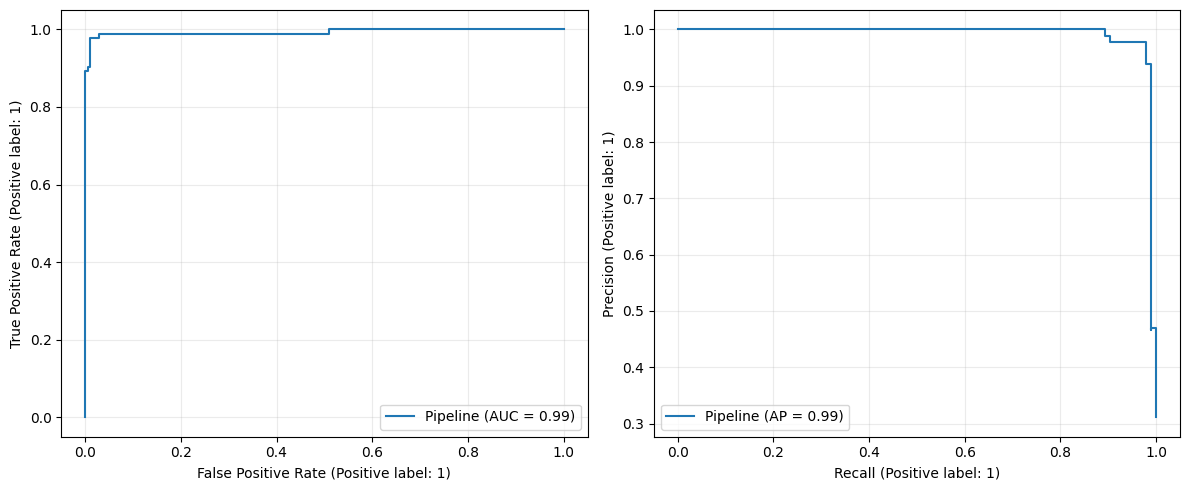

,threshold,precision,recall,f1
39,0.44,0.978,0.978,0.978
36,0.41,0.978,0.978,0.978
37,0.42,0.978,0.978,0.978
38,0.43,0.978,0.978,0.978
40,0.45,0.978,0.978,0.978
41,0.46,0.978,0.978,0.978
32,0.37,0.968,0.978,0.973
34,0.39,0.968,0.978,0.973
35,0.40,0.968,0.978,0.973
33,0.38,0.968,0.978,0.973


best_threshold: 0.44
[[204   2]
 [  2  91]]
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99       206
          불량       0.98      0.98      0.98        93

    accuracy                           0.99       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.99      0.99      0.99       299



In [26]:
best_model_name = metrics.iloc[0]['model']
best_pipe = fitted[best_model_name]
print('best_model:', best_model_name)

# ROC / PR Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(best_pipe, X_test, y_test, ax=axes[0])
PrecisionRecallDisplay.from_estimator(best_pipe, X_test, y_test, ax=axes[1])

axes[0].grid(alpha=0.25)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# F1 기준 threshold 조정
proba = best_pipe.predict_proba(X_test)[:, 1]
threshold_rows = []

for th in np.arange(0.05, 0.96, 0.01):
    pred_th = (proba >= th).astype(int)
    threshold_rows.append({
        'threshold': th,
        'precision': precision_score(y_test, pred_th, zero_division=0),
        'recall': recall_score(y_test, pred_th, zero_division=0),
        'f1': f1_score(y_test, pred_th, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_th = threshold_df.sort_values('f1', ascending=False).iloc[0]
display(threshold_df.sort_values('f1', ascending=False).head(10).round(3))

pred_best_th = (proba >= best_th['threshold']).astype(int)

print('best_threshold:', round(best_th['threshold'], 3))
print(confusion_matrix(y_test, pred_best_th))
print(classification_report(y_test, pred_best_th, target_names=['양품','불량'], zero_division=0))


In [27]:
# 변수 중요도 확인
best_model = fitted['GradientBoosting']
feature_names = feature_cols  # 이미 인코딩된 컬럼명 그대로 사용

importances = best_model.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
print(imp_df.sort_values('importance', ascending=False).head(10))

             feature  importance
3       rolling_temp    0.553149
41            hsb_적용    0.177225
4    descaling_count    0.150094
6          side_area    0.037416
2      fur_soak_time    0.023221
7          temp_diff    0.021118
5       rolling_hour    0.015517
0           pt_width    0.009935
30  spec_long_NV-A32    0.002305
34   spec_country_독일    0.001984


In [28]:
for name, pipe in fitted.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    test_pred = pipe.predict(X_test)
    test_f1 = f1_score(y_test, test_pred)
    print(f'{name}')
    print(f'  CV f1 평균: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')
    print(f'  Test f1:   {test_f1:.3f}')
    print()

Logistic
  CV f1 평균: 0.745 (+/- 0.023)
  Test f1:   0.773

DecisionTree
  CV f1 평균: 0.816 (+/- 0.042)
  Test f1:   0.802

RandomForest
  CV f1 평균: 0.770 (+/- 0.058)
  Test f1:   0.870

GradientBoosting
  CV f1 평균: 0.919 (+/- 0.020)
  Test f1:   0.973

XGBoost
  CV f1 평균: 0.932 (+/- 0.017)
  Test f1:   0.962



### 해석

- 기본 threshold 0.5가 최적이라는 보장은 없습니다.
- F1 기준 threshold는 불량 탐지와 오탐의 균형점입니다. 현장에서는 Recall 우선 threshold를 별도로 선택할 수도 있습니다.


,variable,importance_mean,importance_std
3,rolling_temp,0.529111,0.034633
41,hsb_적용,0.112805,0.007420
4,descaling_count,0.086531,0.011718
7,temp_diff,0.026588,0.006917
2,fur_soak_time,0.019163,0.008382
5,rolling_hour,0.015624,0.009143
6,side_area,0.010812,0.006287
8,spec_long_AB/AH32,0.005303,0.001216
0,pt_width,0.004090,0.005904
35,spec_country_미국,0.000000,0.000000


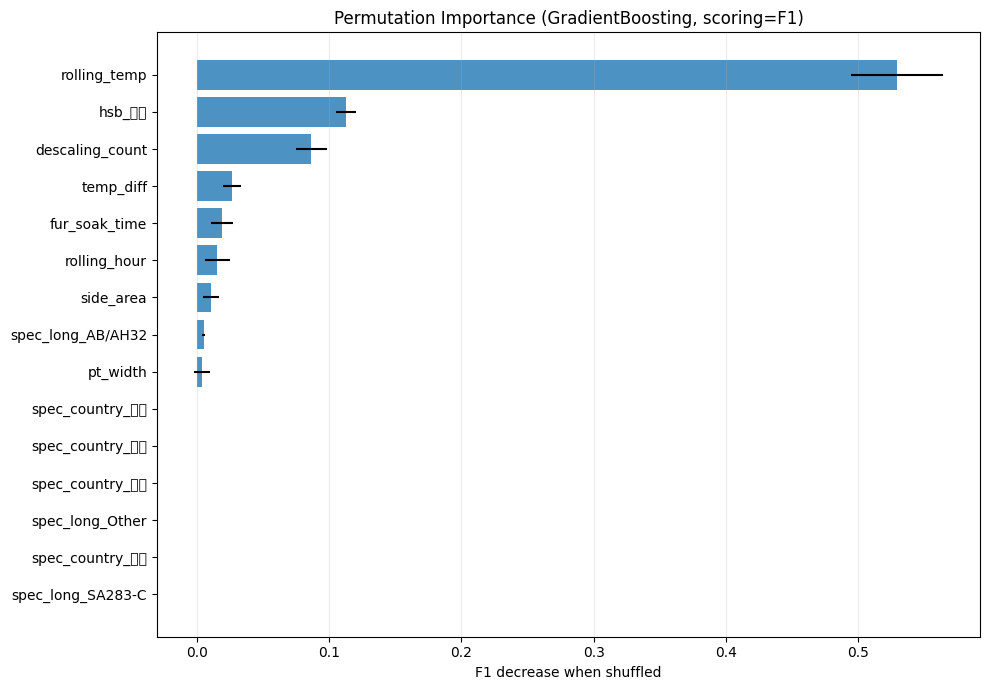

In [29]:
# 퍼뮤테이션 중요도: 모델 구조와 무관하게 원본 변수 단위로 영향 확인
perm = permutation_importance(
    best_pipe, X_test, y_test,
    scoring='f1', n_repeats=20, random_state=42, n_jobs=-1
)

perm_imp = pd.DataFrame({
    'variable': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_imp.head(25))

plt.figure(figsize=(10, 7))
top = perm_imp.head(15).iloc[::-1]
plt.barh(top['variable'], top['importance_mean'], xerr=top['importance_std'], alpha=0.8)
plt.title(f'Permutation Importance ({best_model_name}, scoring=F1)')
plt.xlabel('F1 decrease when shuffled')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


### 해석

- 퍼뮤테이션 중요도는 해당 변수를 섞었을 때 F1이 얼마나 떨어지는지를 봅니다.
- 중요도가 높은 변수는 예측 성능에 실질적으로 기여한 변수입니다. 단, 서로 대체 가능한 공선성 변수는 중요도가 나눠질 수 있습니다.


,feature,coef,abs_coef
41,remainder__hsb_적용,-4.729052,4.729052
40,remainder__steel_kind_T,-1.759245,1.759245
3,num__rolling_temp,1.488532,1.488532
32,remainder__spec_long_PILAC-BT33,-1.403927,1.403927
4,num__descaling_count,-1.124675,1.124675
16,remainder__spec_long_GL-A32,-1.006371,1.006371
23,remainder__spec_long_KR-AH32,0.983660,0.983660
31,remainder__spec_long_Other,0.864367,0.864367
45,remainder__rolling_method_TMCP(온도제어),-0.843330,0.843330
21,remainder__spec_long_JS-SS400,0.828255,0.828255


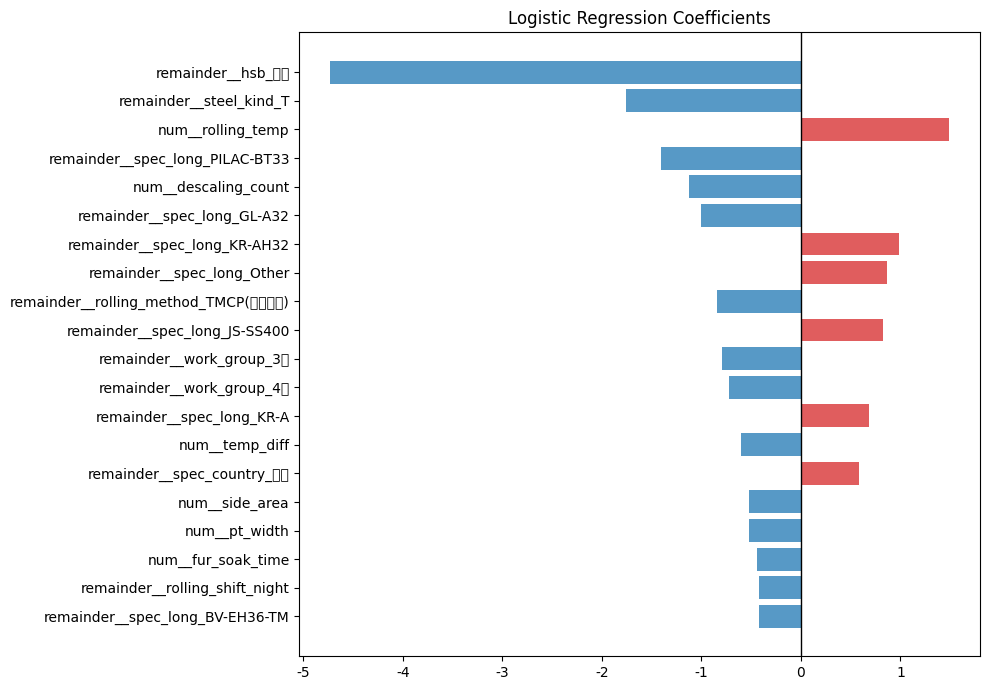

In [30]:
# 로지스틱 회귀 계수: 방향성 확인용
logit_pipe = fitted.get('Logistic')
if logit_pipe is not None:
    prep = logit_pipe.named_steps['prep']
    model = logit_pipe.named_steps['model']
    try:
        feature_names = prep.get_feature_names_out()
    except Exception:
        feature_names = [f'x{i}' for i in range(len(model.coef_[0]))]
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coef': model.coef_[0]
    })
    coef_df['abs_coef'] = coef_df['coef'].abs()
    display(coef_df.sort_values('abs_coef', ascending=False).head(30))

    top_coef = coef_df.sort_values('abs_coef', ascending=False).head(20).iloc[::-1]
    colors = np.where(top_coef['coef'] >= 0, 'tab:red', 'tab:blue')
    plt.figure(figsize=(10, 7))
    plt.barh(top_coef['feature'], top_coef['coef'], color=colors, alpha=0.75)
    plt.axvline(0, color='black', linewidth=1)
    plt.title('Logistic Regression Coefficients')
    plt.tight_layout()
    plt.show()


### 해석

- 양수 계수는 불량 확률 증가 방향, 음수 계수는 불량 확률 감소 방향으로 해석합니다.
- 표준화와 원-핫 인코딩 후 계수이므로 절대값은 상대적 영향 크기 참고용입니다.


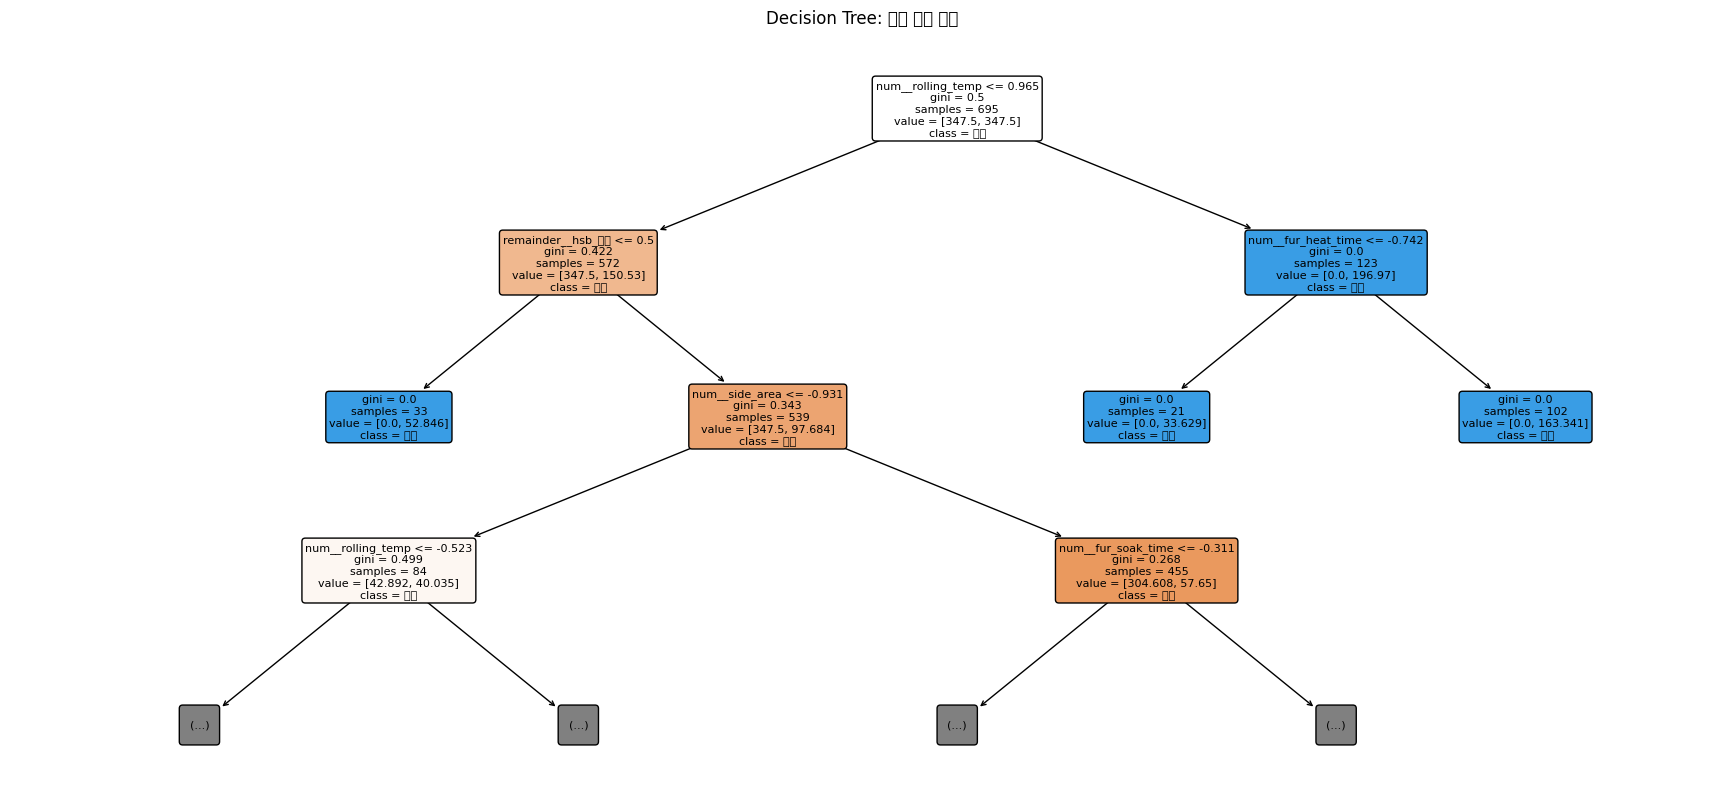

In [31]:
# 의사결정나무 구조 확인: 설명 가능한 규칙 추출
if 'DecisionTree' in fitted:
    tree_pipe = fitted['DecisionTree']
    prep = tree_pipe.named_steps['prep']
    tree = tree_pipe.named_steps['model']
    try:
        tree_features = prep.get_feature_names_out()
    except Exception:
        tree_features = None

    plt.figure(figsize=(22, 10))
    plot_tree(
        tree,
        feature_names=tree_features,
        class_names=['양품','불량'],
        filled=True,
        rounded=True,
        max_depth=3,
        fontsize=8
    )
    plt.title('Decision Tree: 주요 분기 규칙')
    plt.show()


### 해석

- 트리의 상단 분기 변수는 불량/양품을 빠르게 나누는 규칙 후보입니다.
- 발표에서는 “어떤 조건에서 불량 위험이 커지는가”를 설명할 때 트리 규칙을 활용하면 좋습니다.


In [32]:
# 핵심인자 선정표: 통계검정 + 모델 중요도 기반 선정
# 과제 설명에 맞게 사전 우선순위(domain score)는 최종 점수에서 제외한다.
# 기술적 검토는 점수화하지 않고, 최종 해석 단계에서 보조 근거로만 사용한다.
num_score = num_tests[['variable','p_value']].copy()
num_score['test_type'] = 't-test'
cat_score = cat_tests[['variable','p_value']].copy()
cat_score['test_type'] = 'chi-square'
stat_score = pd.concat([num_score, cat_score], ignore_index=True)
stat_score['stat_rank'] = stat_score['p_value'].rank(method='min', ascending=True)

importance_score = perm_imp[['variable','importance_mean']].copy()
importance_score['model_rank'] = importance_score['importance_mean'].rank(method='min', ascending=False)

factor = pd.DataFrame({'variable': feature_cols})
factor = factor.merge(stat_score, on='variable', how='left')
factor = factor.merge(importance_score, on='variable', how='left')

# 점수: 모델 중요도 60점 + 통계검정 40점
# 모델 중요도는 예측 성능 기여도, 통계검정은 양품/불량 차이의 유의성을 의미한다.
factor['model_score'] = factor['model_rank'].max() + 1 - factor['model_rank']
factor['model_score'] = 60 * factor['model_score'] / factor['model_score'].max()
factor['stat_score'] = factor['stat_rank'].max() + 1 - factor['stat_rank']
factor['stat_score'] = 40 * factor['stat_score'] / factor['stat_score'].max()
factor[['model_score','stat_score']] = factor[['model_score','stat_score']].fillna(0)
factor['total_score'] = factor['model_score'] + factor['stat_score']

factor_summary = factor.sort_values('total_score', ascending=False)[[
    'variable','total_score','model_score','stat_score','importance_mean','p_value','test_type'
]].reset_index(drop=True)

def select_reason(row):
    reasons = []
    if pd.notna(row['importance_mean']) and row['importance_mean'] > 0:
        reasons.append('모델 중요도 상위')
    if pd.notna(row['p_value']) and row['p_value'] < 0.05:
        reasons.append('통계 유의')
    return ', '.join(reasons) if reasons else '보조 후보'

factor_summary['선정_사유'] = factor_summary.apply(select_reason, axis=1)
display(factor_summary.head(20).round({'total_score': 1, 'model_score': 1, 'stat_score': 1, 'importance_mean': 4, 'p_value': 4}))


,variable,total_score,model_score,stat_score,importance_mean,p_value,test_type,선정_사유
0,rolling_temp,100.0,60.0,40.0,0.5291,0.0000,t-test,"모델 중요도 상위, 통계 유의"
1,fur_soak_time,85.2,55.2,30.0,0.0192,0.0000,t-test,"모델 중요도 상위, 통계 유의"
2,pt_width,72.9,50.4,22.5,0.0041,0.0000,t-test,"모델 중요도 상위, 통계 유의"
3,side_area,72.8,52.8,20.0,0.0108,0.0000,t-test,"모델 중요도 상위, 통계 유의"
4,temp_diff,68.9,56.4,12.5,0.0266,0.0129,t-test,"모델 중요도 상위, 통계 유의"
5,descaling_count,67.6,57.6,10.0,0.0865,0.1365,t-test,모델 중요도 상위
6,rolling_hour,61.5,54.0,7.5,0.0156,0.1778,t-test,모델 중요도 상위
7,hsb_적용,58.8,58.8,0.0,0.1128,NaN,NaN,모델 중요도 상위
8,fur_heat_time,51.7,49.2,2.5,0.0000,0.2294,t-test,보조 후보
9,spec_long_AB/AH32,51.6,51.6,0.0,0.0053,NaN,NaN,모델 중요도 상위


### 해석

- 최종 핵심인자는 한 가지 기준만으로 정하지 않고, 통계검정 유의성과 모델 중요도를 기준으로 선정합니다.
- 상위 변수 중 열입력, 온도강하, HSB/descaling, 두께 보정 변수가 반복적으로 나타나면 과제 설명서의 잠재 인자와도 일관됩니다.


In [33]:
# 개선 방향 자동 요약 템플릿
top_vars = factor_summary.head(10)['variable'].tolist()
print('Top variables:', top_vars)

recommendations = []
# if any(v in top_vars for v in ['heat_per_thick','pt_thick']):
#     recommendations.append('두꺼운 판은 절대 시간보다 두께 대비 재로시간 기준으로 가열 스케줄을 점검한다.')
if any(v in top_vars for v in ['rolling_temp']):
    recommendations.append('압연온도가 높은 조건에서 Scale 압입 위험을 집중 점검한다.')
# if any(v in top_vars for v in ['hsb','descaling_count','descaling_per_thick']):
#     recommendations.append('HSB 적용 상태와 descaling 횟수/압력/노즐 상태를 점검하고, 고위험 조건에서 제거 공정을 강화한다.')
if any(v in top_vars for v in ['steel_kind','spec_long','rolling_method']):
    recommendations.append('강종·규격·압연방법별로 불량률이 높은 조합에는 별도 작업 표준을 적용한다.')

for i, rec in enumerate(recommendations, 1):
    print(f'{i}. {rec}')


Top variables: ['rolling_temp', 'fur_soak_time', 'pt_width', 'side_area', 'temp_diff', 'descaling_count', 'rolling_hour', 'hsb_적용', 'fur_heat_time', 'spec_long_AB/AH32']
1. 압연온도가 높은 조건에서 Scale 압입 위험을 집중 점검한다.


### 최종 해석 요약

- Scale 불량은 단순히 한 변수의 문제가 아니라, 고온 노출 조건과 제거 공정 조건이 함께 작용하는 분류 문제로 보는 것이 적절합니다.
- 핵심인자는 사전 우선순위 점수 없이 `통계검정 유의성`과 `모델 중요도`를 기준으로 선정했습니다.
- `fur_*_temp`, `fur_*_time`, 열입력 파생변수, `rolling_temp`, `hsb`, `descaling_count`, `pt_thick` 계열 변수가 상위에 오르면 과제 설명의 잠재 인자와 분석 결과가 잘 맞습니다.
- 개선안은 “고온 장시간 체류 조건 관리”, “두께 대비 재로시간 관리”, “압연온도 관리”, “HSB/descaling 설비 점검 및 조건 강화”로 정리할 수 있습니다.
- `work_group`, `fur_no` 같은 비공정성 변수가 높게 나오면 인적 편차 또는 설비 편차가 숨어 있다는 신호이므로 추가 원인분석 대상으로 둡니다.


In [34]:
# 선택: 핵심인자 선정표 저장
# openpyxl이 있으면 xlsx, 없으면 csv로 저장합니다.
output_xlsx = PROJECT_DIR / 'scale_key_factor_summary.xlsx'
output_csv = PROJECT_DIR / 'scale_key_factor_summary.csv'
try:
    factor_summary.to_excel(output_xlsx, index=False)
    print('saved:', output_xlsx)
except ModuleNotFoundError:
    factor_summary.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print('openpyxl 미설치로 csv 저장:', output_csv)


openpyxl 미설치로 csv 저장: /Users/jihyun/Documents/포빅아/빅데이터/종합실습2/scale_key_factor_summary.csv


---------

#### 최종결과 확인

In [35]:
# T검정 결과 (순위)
print("T검정 결과")
print(num_tests[['variable', 'p_value']].reset_index(drop=True))

# 카이제곱 결과 (순위)
print("카이제곱 결과")
print(cat_tests[['variable', 'p_value']].reset_index(drop=True))

T검정 결과
          variable       p_value
0     rolling_temp  6.790361e-66
1    fur_soak_time  2.941014e-15
2         pt_width  1.647683e-09
3        side_area  3.648726e-08
4        temp_diff  1.291017e-02
5  descaling_count  1.364503e-01
6     rolling_hour  1.777905e-01
7    fur_heat_time  2.294096e-01
카이제곱 결과
         variable       p_value
0             hsb  9.439705e-25
1       spec_long  3.113316e-21
2      steel_kind  2.489547e-18
3    spec_country  4.492256e-13
4  rolling_method  2.094833e-11
5      work_group  3.043656e-03
6   rolling_shift  5.135637e-03
7          fur_no  2.102809e-01
8   fur_input_row  3.373786e-01


In [36]:
for name, pipe in fitted.items():
    model = pipe.named_steps['model']
    if hasattr(model, 'feature_importances_'):
        imp = pd.DataFrame({
            'feature': feature_cols,  # feature_cols 그대로 사용
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False).reset_index(drop=True)
        imp.index += 1
        print(f'\n{"="*40}')
        print(f'{name} 변수 중요도 (상위 10개)')
        print(imp.head(10))


DecisionTree 변수 중요도 (상위 10개)
             feature    importance
1       rolling_temp  6.391914e-01
2             hsb_적용  2.571110e-01
3          side_area  6.313438e-02
4      fur_soak_time  4.056323e-02
5      fur_heat_time  5.772517e-14
6           pt_width  0.000000e+00
7    spec_country_일본  0.000000e+00
8     spec_long_NV-A  0.000000e+00
9   spec_long_NV-A32  0.000000e+00
10   spec_long_Other  0.000000e+00

RandomForest 변수 중요도 (상위 10개)
                      feature  importance
1                rolling_temp    0.323969
2                    pt_width    0.095944
3                steel_kind_T    0.082654
4               fur_soak_time    0.076285
5                      hsb_적용    0.068563
6             descaling_count    0.065440
7                   side_area    0.061848
8                rolling_hour    0.034709
9                   temp_diff    0.030677
10  rolling_method_TMCP(온도제어)    0.024202

GradientBoosting 변수 중요도 (상위 10개)
             feature  importance
1       rolling_temp    0.

In [37]:
pipe = fitted['Logistic']
model = pipe.named_steps['model']

coef_df = pd.DataFrame({
    'feature': feature_cols,  # feature_cols 그대로 사용
    'coefficient': abs(model.coef_[0])
}).sort_values('coefficient', ascending=False).reset_index(drop=True)
coef_df.index += 1

print('Logistic 변수 중요도 (상위 10개)')
print(coef_df.head(10))

Logistic 변수 중요도 (상위 10개)
                      feature  coefficient
1                      hsb_적용     4.729052
2                steel_kind_T     1.759245
3                rolling_temp     1.488532
4        spec_long_PILAC-BT33     1.403927
5             descaling_count     1.124675
6            spec_long_GL-A32     1.006371
7           spec_long_KR-AH32     0.983660
8             spec_long_Other     0.864367
9   rolling_method_TMCP(온도제어)     0.843330
10         spec_long_JS-SS400     0.828255
